In [ ]:
# =========================
# Upload and Extract Dataset
# =========================

from google.colab import files
uploaded = files.upload()

Saving microstructure_dataset.zip to microstructure_dataset.zip


In [ ]:
# =========================
# Extract Dataset Files
# =========================
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print(os.listdir("dataset"))

['microstructure_dataset']


In [ ]:
!pip install segmentation-models -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.7 MB/s eta 0:00:00


In [ ]:
# =========================
# Install Required Libraries
# =========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [ ]:
# =========================
# Define Dataset Paths
# =========================
base_path = "dataset/microstructure_dataset"

image_path = os.path.join(base_path, "images")
mask_path = os.path.join(base_path, "masks")

print("Image folders:", os.listdir(image_path))
print("Mask folders:", os.listdir(mask_path))

Image folders: ['mixed', 'martensite']
Mask folders: ['.ipynb_checkpoints', 'mixed', 'martensite']


In [ ]:

IMG_SIZE = 256
classes = ["martensite", "mixed"]

images = []
masks = []

for cls in classes:
    img_folder = os.path.join(image_path, cls)
    mask_folder = os.path.join(mask_path, cls)

    for filename in os.listdir(img_folder):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            img_file = os.path.join(img_folder, filename)
            mask_file = os.path.join(mask_folder, filename)

            if os.path.exists(img_file) and os.path.exists(mask_file):
                img = cv2.imread(img_file)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0

                mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

                images.append(img)
                masks.append(mask)
            else:
                print("Missing mask for:", filename)

images = np.array(images, dtype=np.float32)
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Unique mask values:", np.unique(masks))

Missing mask for: martensite_11.png
Missing mask for: mixed_15.png
Images shape: (25, 256, 256, 3)
Masks shape: (25, 256, 256)
Unique mask values: [  0  74 169 211]


In [ ]:
# Convert CVAT colors to class IDs

mask_fixed = np.zeros_like(masks)

mask_fixed[masks == 0] = 0      # background
mask_fixed[masks == 74] = 1     # class 1
mask_fixed[masks == 169] = 2    # class 2
mask_fixed[masks == 211] = 3    # class 3

masks = mask_fixed

print("New mask values:", np.unique(masks))

New mask values: [0 1 2 3]


In [ ]:


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

# Convert masks to one-hot encoding
num_classes = 4

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)
print("Training masks:", y_train.shape)
print("Testing masks:", y_test.shape)

Training images: (20, 256, 256, 3)
Testing images: (5, 256, 256, 3)
Training masks: (20, 256, 256, 4)
Testing masks: (5, 256, 256, 4)


In [ ]:
# Check which images are in test set
print("Test set size:", X_test.shape)

Test set size: (5, 256, 256, 3)


In [ ]:
# =========================
# Load Images and Masks
# =========================
image_names = []
images = []
masks = []

for cls in classes:
    img_folder = os.path.join(image_path, cls)
    mask_folder = os.path.join(mask_path, cls)

    for filename in os.listdir(img_folder):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            img_file = os.path.join(img_folder, filename)
            mask_file = os.path.join(mask_folder, filename)

            if os.path.exists(mask_file):
                img = cv2.imread(img_file)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

                mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

                images.append(img)
                masks.append(mask)
                image_names.append(cls + "/" + filename)

images = np.array(images, dtype=np.float32)
masks = np.array(masks)
image_names = np.array(image_names)

In [ ]:
X_train, X_test, y_train_raw, y_test_raw, names_train, names_test = train_test_split(
    images, masks, image_names, test_size=0.2, random_state=42
)

print("Test images:")
for name in names_test:
    print(name)

Test images:
martensite/martensite_6.png
mixed/mixed_11.png
martensite/martensite_1.2.png
mixed/mixed_4.png
martensite/martensite_10.png


In [ ]:
manual_test_names = [
    "mixed/mixed_11.png",
    "martensite/martensite_1.2.png",
    "martensite/martensite_10.png",
    "mixed/mixed_14.png",
    "martensite/martensite_9.png"
]

In [ ]:
# Convert CVAT grayscale mask values into class IDs
mask_fixed = np.zeros_like(masks)

mask_fixed[masks == 0] = 0
mask_fixed[masks == 74] = 1
mask_fixed[masks == 169] = 2
mask_fixed[masks == 211] = 3

masks = mask_fixed.astype(np.uint8)

print("Fixed mask values:", np.unique(masks))

Fixed mask values: [0 1 2 3]


In [ ]:
# =========================
# Split Training and Testing Data
# =========================
test_mask = np.isin(image_names, manual_test_names)

X_test = images[test_mask]
y_test_raw = masks[test_mask]
names_test = image_names[test_mask]

X_train = images[~test_mask]
y_train_raw = masks[~test_mask]
names_train = image_names[~test_mask]

y_train = to_categorical(y_train_raw, num_classes=4)
y_test = to_categorical(y_test_raw, num_classes=4)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("Test images:")
for name in names_test:
    print(name)

Train: (20, 256, 256, 3)
Test: (5, 256, 256, 3)
Test images:
martensite/martensite_1.2.png
martensite/martensite_9.png
martensite/martensite_10.png
mixed/mixed_14.png
mixed/mixed_11.png


In [ ]:
# =========================
# Build U-Net Architecture
# =========================
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

inputs = Input((256,256,3))

# Encoder
c1 = Conv2D(16,(3,3),activation='relu',padding='same')(inputs)
c1 = Conv2D(16,(3,3),activation='relu',padding='same')(c1)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(32,(3,3),activation='relu',padding='same')(p1)
c2 = Conv2D(32,(3,3),activation='relu',padding='same')(c2)
p2 = MaxPooling2D((2,2))(c2)

c3 = Conv2D(64,(3,3),activation='relu',padding='same')(p2)
c3 = Conv2D(64,(3,3),activation='relu',padding='same')(c3)

# Decoder
u1 = UpSampling2D((2,2))(c3)
u1 = concatenate([u1,c2])

c4 = Conv2D(32,(3,3),activation='relu',padding='same')(u1)
c4 = Conv2D(32,(3,3),activation='relu',padding='same')(c4)

u2 = UpSampling2D((2,2))(c4)
u2 = concatenate([u2,c1])

c5 = Conv2D(16,(3,3),activation='relu',padding='same')(u2)
c5 = Conv2D(16,(3,3),activation='relu',padding='same')(c5)

outputs = Conv2D(4,(1,1),activation='softmax')(c5)

model = Model(inputs=[inputs], outputs=[outputs])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,324 (462.20 KB)

 Trainable params: 118,324 (462.20 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
# =========================
# Initial Model Training
# =========================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=4
)

NameError: name 'model' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


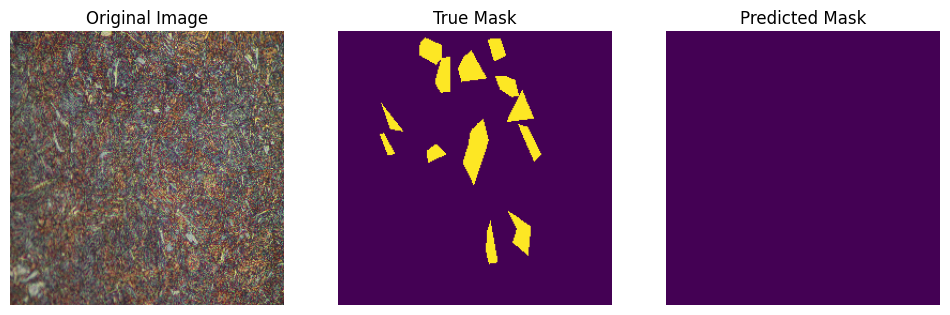

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

index = 0

prediction = model.predict(X_test[index:index+1])
predicted_mask = np.argmax(prediction[0], axis=-1)
true_mask = np.argmax(y_test[index], axis=-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(X_test[index])
plt.axis("off")

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(true_mask)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(predicted_mask)
plt.axis("off")

plt.show()

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# =========================
# Data Augmentation
# =========================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=4),
    validation_data=(X_test, y_test),
    epochs=30
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7536 - loss: 0.7042 - val_accuracy: 0.7592 - val_loss: 0.9526
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.7536 - loss: 0.7462 - val_accuracy: 0.7592 - val_loss: 0.6836
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.7536 - loss: 0.6690 - val_accuracy: 0.7592 - val_loss: 0.9009
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7536 - loss: 0.6915 - val_accuracy: 0.7592 - val_loss: 0.7108
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.7536 - loss: 0.6874 - val_accuracy: 0.7592 - val_loss: 0.7354
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.7536 - loss: 0.6714 - val_accuracy: 0.7592 - val_loss: 0.8142
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7536 - loss: 0.6525 - val_accuracy: 0.7592 - val_loss: 0.7153
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7536 - loss: 0.6588 - val_accuracy: 0.7592 - val_loss: 0.6969
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step


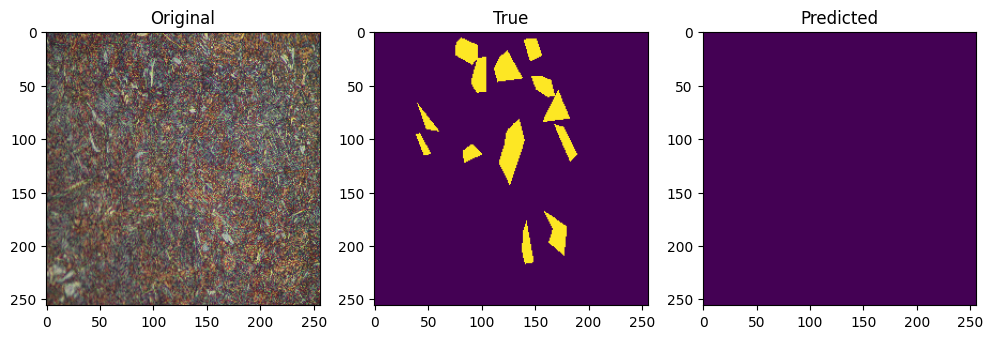

In [ ]:

index = 0

prediction = model.predict(X_test[index:index+1])
predicted_mask = np.argmax(prediction[0], axis=-1)
true_mask = np.argmax(y_test[index], axis=-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(X_test[index])

plt.subplot(1,3,2)
plt.title("True")
plt.imshow(true_mask)

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(predicted_mask)

plt.show()

In [ ]:
# Find mixed images in test set
for i, name in enumerate(names_test):
    if "mixed" in name:
        print(i, name)

3 mixed/mixed_14.png
4 mixed/mixed_11.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


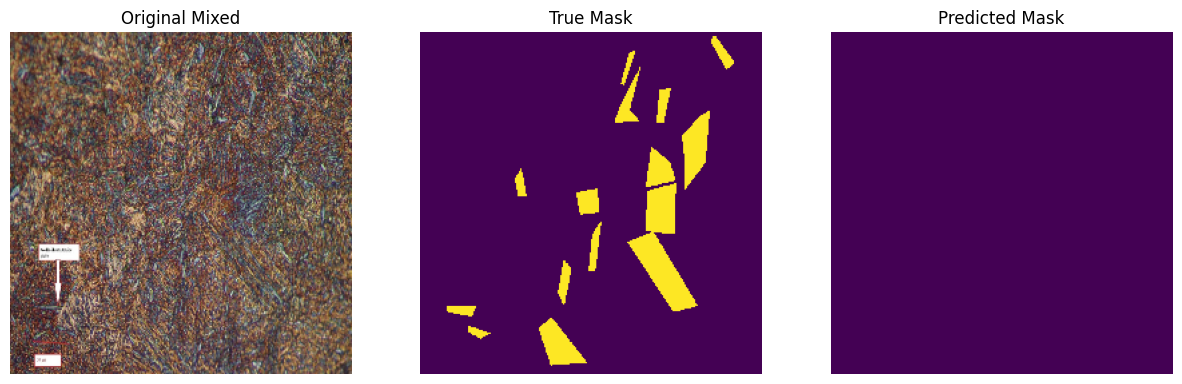

In [ ]:
index = 1   # replace with the mixed image index

prediction = model.predict(X_test[index:index+1])
predicted_mask = np.argmax(prediction[0], axis=-1)
true_mask = np.argmax(y_test[index], axis=-1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Mixed")
plt.imshow(X_test[index])
plt.axis("off")

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(true_mask)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(predicted_mask)
plt.axis("off")

plt.show()

In [ ]:
for i, name in enumerate(names_test):
    print(i, name)

0 martensite/martensite_1.2.png
1 martensite/martensite_9.png
2 martensite/martensite_10.png
3 mixed/mixed_14.png
4 mixed/mixed_11.png


In [ ]:
index = 3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


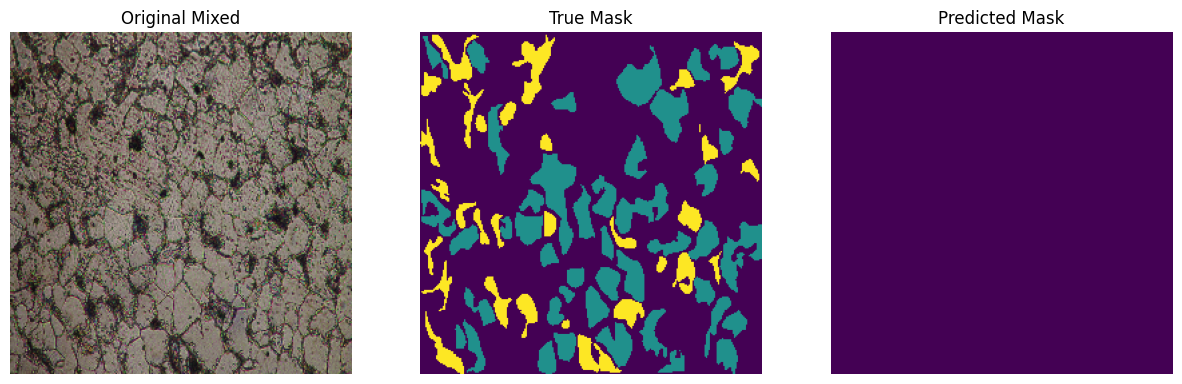

In [ ]:
prediction = model.predict(X_test[index:index+1])
predicted_mask = np.argmax(prediction[0], axis=-1)
true_mask = np.argmax(y_test[index], axis=-1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Mixed")
plt.imshow(X_test[index])
plt.axis("off")

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(true_mask)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(predicted_mask)
plt.axis("off")

plt.show()

In [ ]:
# =========================
# Define Dice Loss Function
# =========================
import tensorflow as tf

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1, 4])
    y_pred_f = tf.reshape(y_pred, [-1, 4])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)

    dice = (2. * intersection + smooth) / (denominator + smooth)
    return 1 - tf.reduce_mean(dice)

def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return ce + dl

In [ ]:
model.compile(
    optimizer='adam',
    loss=combined_loss,
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=4
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7322 - loss: 1.4032 - val_accuracy: 0.8017 - val_loss: 1.4302
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7472 - loss: 1.3483 - val_accuracy: 0.7592 - val_loss: 1.8258
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7697 - loss: 1.3267 - val_accuracy: 0.7595 - val_loss: 1.4975
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7650 - loss: 1.3215 - val_accuracy: 0.7600 - val_loss: 1.4681
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7660 - loss: 1.3289 - val_accuracy: 0.7595 - val_loss: 1.5215
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.7439 - loss: 1.3600 - val_accuracy: 0.7774 - val_loss: 1.3960
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7614 - loss: 1.3204 - val_accuracy: 0.7592 - val_loss: 1.6744
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7818 - loss: 1.2994 - val_accuracy: 0.7597 - val_loss: 1.4694
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


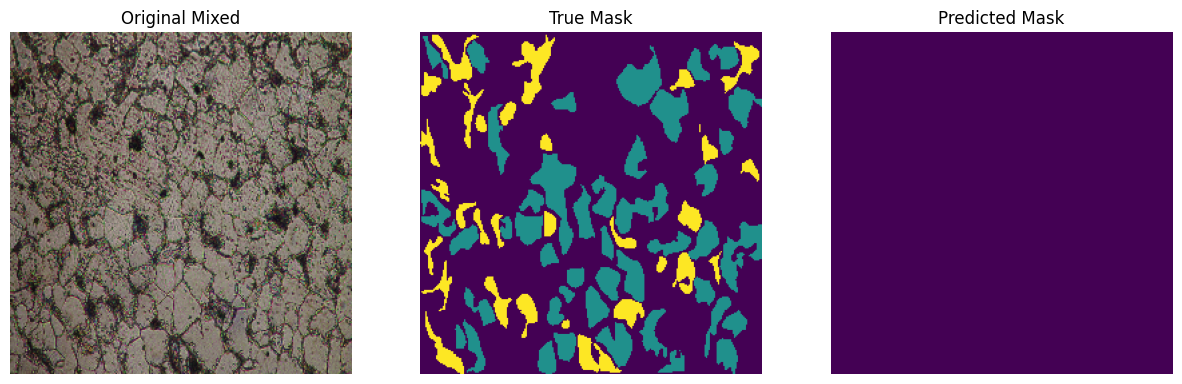

In [ ]:
index = 3  # mixed_14

prediction = model.predict(X_test[index:index+1])
predicted_mask = np.argmax(prediction[0], axis=-1)
true_mask = np.argmax(y_test[index], axis=-1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Mixed")
plt.imshow(X_test[index])
plt.axis("off")

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(true_mask)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(predicted_mask)
plt.axis("off")

plt.show()

In [ ]:
# =========================
# Calculate Class Weights
# =========================
import tensorflow as tf
import numpy as np

# Count pixels for each class in training masks
class_counts = np.sum(y_train_raw[..., None] == np.arange(4), axis=(0,1,2))
total_pixels = np.sum(class_counts)

class_weights = total_pixels / (4 * class_counts)
class_weights = class_weights / np.mean(class_weights)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [987713 191529  14100 117378]
Class weights: [0.04726883 0.24376485 3.31120833 0.39775799]


In [ ]:
class_weights_tf = tf.constant(class_weights, dtype=tf.float32)

def weighted_categorical_crossentropy(y_true, y_pred):
    weights = tf.reduce_sum(class_weights_tf * y_true, axis=-1)
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return ce * weights

In [ ]:
# =========================
# Retrain Model with Weighted Loss
# =========================
model.compile(
    optimizer='adam',
    loss=weighted_categorical_crossentropy,
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=4
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7547 - loss: 0.1825 - val_accuracy: 0.7660 - val_loss: 0.2682
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7177 - loss: 0.1712 - val_accuracy: 0.8192 - val_loss: 0.2520
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6814 - loss: 0.1675 - val_accuracy: 0.7539 - val_loss: 0.2597
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6610 - loss: 0.1658 - val_accuracy: 0.7869 - val_loss: 0.2334
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5140 - loss: 0.1627 - val_accuracy: 0.7221 - val_loss: 0.1965
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5609 - loss: 0.1525 - val_accuracy: 0.6792 - val_loss: 0.2182
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4186 - loss: 0.1432 - val_accuracy: 0.4268 - val_loss: 0.1575
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3190 - loss: 0.1638 - val_accuracy: 0.3671 - val_loss: 0.3238
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


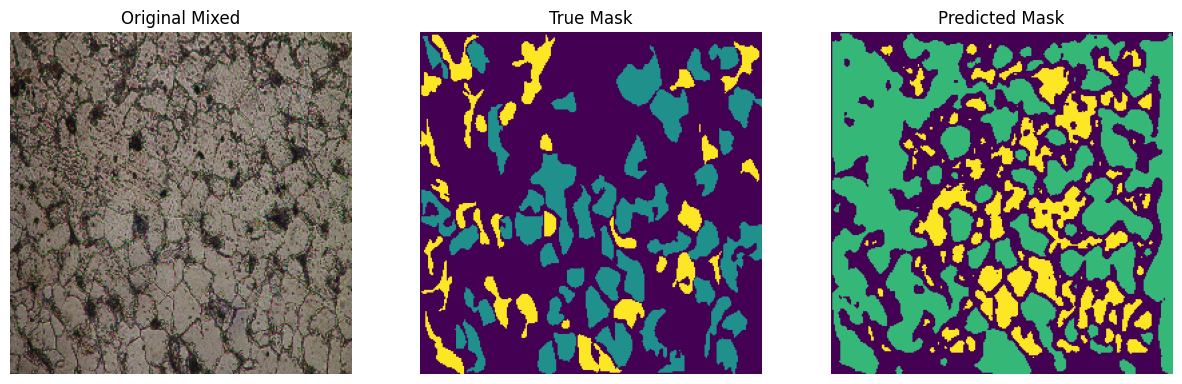

In [ ]:
index = 3

prediction = model.predict(X_test[index:index+1])
predicted_mask = np.argmax(prediction[0], axis=-1)
true_mask = np.argmax(y_test[index], axis=-1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Mixed")
plt.imshow(X_test[index])
plt.axis("off")

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(true_mask)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(predicted_mask)
plt.axis("off")

plt.show()

In [ ]:

# =========================
# Evaluate Model Performance
# =========================
from tensorflow.keras.metrics import MeanIoU

prediction = model.predict(X_test)

pred_masks = np.argmax(prediction, axis=-1)
true_masks = np.argmax(y_test, axis=-1)

iou_metric = MeanIoU(num_classes=4)
iou_metric.update_state(true_masks, pred_masks)

print("Mean IoU:", iou_metric.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Mean IoU: 0.24624445


In [ ]:
# =========================
# Save Trained Model
# =========================
model.save("microstructure_unet.keras")

In [ ]:
# =========================
# Save Trained Model
# ==========================
model.save("microstructure_unet_model.h5")

In [ ]:
# =========================
# Download Trained Model
# =========================
from google.colab import files
files.download("microstructure_unet_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>